In [41]:
# imports
# !pip install graphviz
from graphviz import Digraph
import math

# given a graph, return a set of nodes and edges



In [84]:
# Value class

# what do we actually want out of this thing again??


class Value:
    def __init__(self, d, _children=(), lb=''):
        self._backward = lambda: None
        self._prev = set(_children) # done for efficiency (??? but you iterate over it so really who gaf) 
        self.data = d
        self.grad = 0.0
        self._op = ''
        self.label = lb

    def __add__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        out = Value(self.data + other.data, (self, other))
        def _backwards():
            # if f = a + b, df/da = 1 and df/db = 1, and * out.grad because chain rule (d(something else)/da = d(something else)/df * df/da)
            # += and not = because what if f = a + a? want df/da to be 2, not 1, and in the non-duplicate case += only happens once so equivalent to =
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backwards
        out._op = '+'
        return out

    def __neg__(self):
        out = Value(self.data *-1, (self,))
        def _backwards():
            # if f = a - b, df/da = 1 and df/db = - 1
            self.grad += -1.0 * out.grad
        out._backward = _backwards
        out._op = '-'
        return out

    def __sub__(self, other):
        return self + other.__neg__()

    def __mul__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        out = Value(self.data * other.data, (self, other))
        def _backwards():
            # if f = a*b, df/da = b and df/db = a
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backwards
        out._op = '*'
        return out
    
    # when we try to do 2.__add__(a) it will freak out and check if a has rmul to call so this is for that
    def __rmul__(self, other):
        return self.__mul__(other)
    
    def __radd__(self, other): # other + self
        return self.__add__(other)

    def tanh(self):
        x = self.data
        invtan = (math.exp(2*x) - 1)/(math.exp(2*x) + 1) # shoutout wikipedia!!
        out = Value(invtan, (self, ))
        out._op = 'tanh' # oops
        def _backward():
            self.grad += (1 - invtan**2) * out.grad

        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ))
        out._op = 'exp'
        def _backwards():
            self.grad += out.data * out.grad # derivative of e^x is just e^x so data = grad

        out._backward = _backwards
        return out

    def backwards(self):
        def toposort(g):
            # how do you toposort again??
            # start by dfs-ing
            # this will visit all deepest nodes first i think??
            # so we like that
            # "reverse dfs postorder" hmmm
            # so what this means is if i visit some node, i need to visit all its children first
            # and eventually once ive visited all its
            ordered = []
            seen = set()
            def visit(v):
                if v not in seen:
                    seen.add(v)
                    for child in v._prev:
                        visit(child)
                    ordered.append(v)
            visit(g)
            return ordered
        
        ts = toposort(self)
        self.grad = 1.0
        for value in reversed(ts):
            value._backward()



In [22]:
# trying to visualize the graph using just the graphviz docs lmao

def get_V_and_E_from_value_obj(v):
    # wait gang this is just bf/dfs?? no one gaf?? just add yourself and then add your children
    V = set()
    E = set()
    
    def add_node_and_kids(vertex):
        if vertex not in V:
            V.add(vertex)
            for kid in vertex._prev:
                E.add((kid, vertex))
                add_node_and_kids(kid)
    
    add_node_and_kids(v)
    return V, E

# this part i did refer to the draw_dot function but only for syntax!
def draw_expr_graph(value):
    g = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    vertices, edges = get_V_and_E_from_value_obj(value)
    for vertex in vertices:
        uid = str(id(vertex))
        g.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (vertex.label, vertex.data, vertex.grad), shape='record')
        if vertex._op:
            g.node(name=uid + vertex._op, label=vertex._op)
            g.edge(uid + vertex._op, uid)
    
    for source, target in edges:
        if target._op:
            g.edge(str(id(source)), str(id(target)) + target._op)
    
    return g
        



In [88]:
a = Value(2.0, lb='a')
b = Value(3.0, lb='b')
c = a+b
c.label = 'c'
d = Value(17.0, lb='d')
f = d*c
f.label = 'f'
g = Value(3.0, lb='g')
exponentiated_g = g.exp()
h = f + exponentiated_g
j = h.tanh()



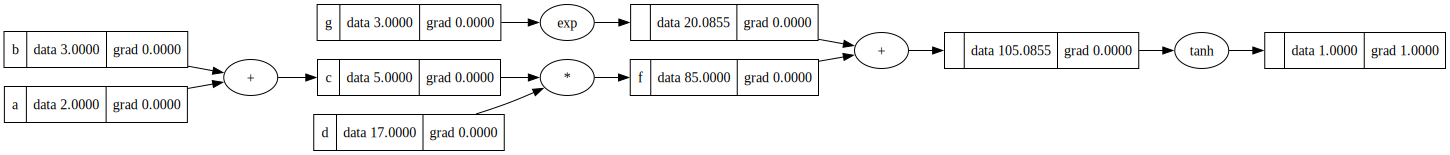

In [102]:
draw_expr_graph(j)

In [101]:
j.backwards()

j._backward()

In [ ]:
# cool now we toposort this thing and call backwards everywhere! initialize grad of the final function to 1




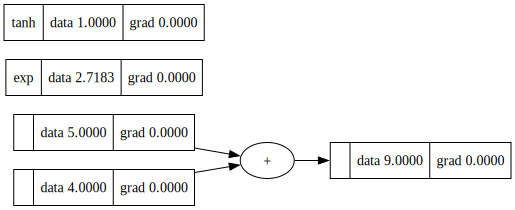

In [80]:
a = Value(4.0)
b = Value(5.0)
c = a + b
d = c.tanh()
e = d.exp()
draw_expr_graph(e)


In [95]:
# "gradient checks"
def grad_check(f, x_val, h=1e-5):
    # using backwards
    x = Value(x_val)
    y = f(x)
    y.backwards()
    analytic = x.grad
    # the f(x+h) way
    numeric = (f(Value(x_val + h)).data - f(Value(x_val - h)).data) / (2*h)
    print(analytic, " vs ", numeric)
    assert abs(analytic - numeric) < 1e-4, f"{analytic} vs {numeric}"

In [96]:
for x_val in [-50, -3, -0.5, -1e-3, 0.0, 1e-3, 0.5, 3, 50]:
    grad_check(lambda x: x.tanh(), x_val)
print("tanh works!")

for x_val in [-10, -1, 0.0, 1, 10]:
    grad_check(lambda x: x.exp(), x_val)
print("exp works!")

0.0  vs  0.0
0.00986603716543999  vs  0.009866037170569442
0.7864477329659274  vs  0.7864477329505569
0.9999990000006667  vs  0.9999989999672528
1.0  vs  0.9999999999648378
0.9999990000006667  vs  0.99999899997108
0.7864477329659274  vs  0.786447732956108
0.009866037165440211  vs  0.009866037165018327
0.0  vs  0.0
tanh works!
4.5399929762484854e-05  vs  4.539992976151192e-05
0.36787944117144233  vs  0.3678794411765551
1.0  vs  1.0000000000121023
2.718281828459045  vs  2.718281828517632
22026.465794806718  vs  22026.46579426073
exp works!
